# BBC News Topic Modeling (LDA)

## Overview
Unsupervised topic modeling on the BBC News dataset (2,225 articles across
5 categories: business, entertainment, politics, sport, tech) using Latent
Dirichlet Allocation (LDA) — with no category labels used during training.

## Approach
1. Cleaning: lowercased text, stripped punctuation/numbers, removed duplicates
2. **Preprocessing**: stopword removal + lemmatization (NLTK)
3. **Vectorization**: CountVectorizer (bag-of-words), min_df=5, max_df=0.9
4. **Modeling**: scikit-learn LatentDirichletAllocation, 5 topics
5. **Evaluation**: mapped each discovered topic to its best-matching real
   category and compared against ground truth

## Results
- **89.98% alignment** between LDA-discovered topics and true article categories
- 4 of 5 categories (business, politics, sport, tech) formed clean, distinct topics
- entertainment and tech showed some vocabulary overlap, reflecting genuine
  real-world topic similarity (gadgets/gaming content in both)
- Built and tested a `predict_topic()` function that classifies new, unseen
  articles — verified correct on 5 hand-written test articles, one per category

## Tools
Python · pandas · NLTK · scikit-learn (CountVectorizer, LatentDirichletAllocation)
· matplotlib/seaborn · WordCloud

In [1]:
!pip install nltk scikit-learn pandas matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

import nltk

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

print("NLTK resources downloaded successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


NLTK resources downloaded successfully!


In [4]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

print("Number of English stopwords:", len(stop_words))

Number of English stopwords: 198


In [5]:
from google.colab import files
uploaded = files.upload()

Saving bbc-text.csv to bbc-text.csv


In [8]:
df = pd.read_csv("bbc-text.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (2225, 2)


In [9]:
df.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  2225 non-null   object
 1   text      2225 non-null   object
dtypes: object(2)
memory usage: 34.9+ KB


In [12]:
df.duplicated().sum()

np.int64(99)

In [13]:
df = df.drop_duplicates().reset_index(drop=True)

In [14]:
df.shape

(2126, 2)

In [15]:
df["clean_text"] = df["text"].copy()

In [16]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df["clean_text"] = df["text"].apply(clean_text)

In [17]:
df[["text", "clean_text"]].head()

,text,clean_text
0,tv future in the hands of viewers with home th...,tv future in the hands of viewers with home th...
1,worldcom boss left books alone former worldc...,worldcom boss left books alone former worldcom...
2,tigers wary of farrell gamble leicester say ...,tigers wary of farrell gamble leicester say th...
3,yeading face newcastle in fa cup premiership s...,yeading face newcastle in fa cup premiership s...
4,ocean s twelve raids box office ocean s twelve...,ocean s twelve raids box office ocean s twelve...


In [18]:
df["tokens"] = df["clean_text"].apply(lambda x: x.split())

In [19]:
def preprocess_tokens(tokens):
    # Remove stopwords (the, is, and...) — they carry no topic-distinguishing signal
    # Lemmatize (running -> run, better -> good) so LDA treats word variants as one concept
    return [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 2]

df["processed_tokens"] = df["tokens"].apply(preprocess_tokens)
df[["tokens", "processed_tokens"]].head()

,tokens,processed_tokens
0,"[tv, future, in, the, hands, of, viewers, with...","[future, hand, viewer, home, theatre, system, ..."
1,"[worldcom, boss, left, books, alone, former, w...","[worldcom, bos, left, book, alone, former, wor..."
2,"[tigers, wary, of, farrell, gamble, leicester,...","[tiger, wary, farrell, gamble, leicester, say,..."
3,"[yeading, face, newcastle, in, fa, cup, premie...","[yeading, face, newcastle, cup, premiership, s..."
4,"[ocean, s, twelve, raids, box, office, ocean, ...","[ocean, twelve, raid, box, office, ocean, twel..."


In [20]:
df["final_text"] = df["processed_tokens"].apply(lambda tokens: " ".join(tokens))
df["final_text"].head()

,final_text
0,future hand viewer home theatre system plasma ...
1,worldcom bos left book alone former worldcom b...
2,tiger wary farrell gamble leicester say rushed...
3,yeading face newcastle cup premiership side ne...
4,ocean twelve raid box office ocean twelve crim...


In [21]:
vectorizer = CountVectorizer(
    max_df=0.9,      # ignore words appearing in >90% of docs (too common, not topic-specific)
    min_df=5,        # ignore words appearing in fewer than 5 docs (too rare, noise)
    stop_words='english'
)

doc_term_matrix = vectorizer.fit_transform(df["final_text"])
print("Document-term matrix shape:", doc_term_matrix.shape)

Document-term matrix shape: (2126, 7655)


In [22]:
n_topics = 5  # we know there are 5 real categories in this dataset — good sanity-check choice

lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    max_iter=10,
    learning_method='online'
)

lda_model.fit(doc_term_matrix)
print("LDA model trained.")

LDA model trained.


In [23]:
def display_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_indices]
        print(f"Topic #{topic_idx}: {', '.join(top_words)}")

feature_names = vectorizer.get_feature_names_out()
display_topics(lda_model, feature_names, n_top_words=10)

Topic #0: said, year, company, market, firm, sale, bank, price, share, new
Topic #1: said, people, game, music, technology, mobile, new, phone, year, service
Topic #2: film, best, award, year, star, said, actor, director, oscar, new
Topic #3: said, government, labour, party, people, election, say, minister, blair, tory
Topic #4: said, game, player, england, win, year, world, time, club, play


In [24]:
topic_distributions = lda_model.transform(doc_term_matrix)   # shape: (n_docs, n_topics), each row sums to 1
df["dominant_topic"] = topic_distributions.argmax(axis=1)
df[["category", "dominant_topic"]].head(10)

,category,dominant_topic
0,tech,1
1,business,3
2,sport,4
3,sport,4
4,entertainment,2
5,politics,3
6,politics,3
7,sport,4
8,sport,4
9,entertainment,2


In [25]:
comparison = pd.crosstab(df["category"], df["dominant_topic"])
print(comparison)

dominant_topic    0    1    2    3    4
category                               
business        466    9    0   28    0
entertainment     4   93  242   30    0
politics         17    2    0  384    0
sport             0    0    1    8  495
tech              7  326    2   10    2


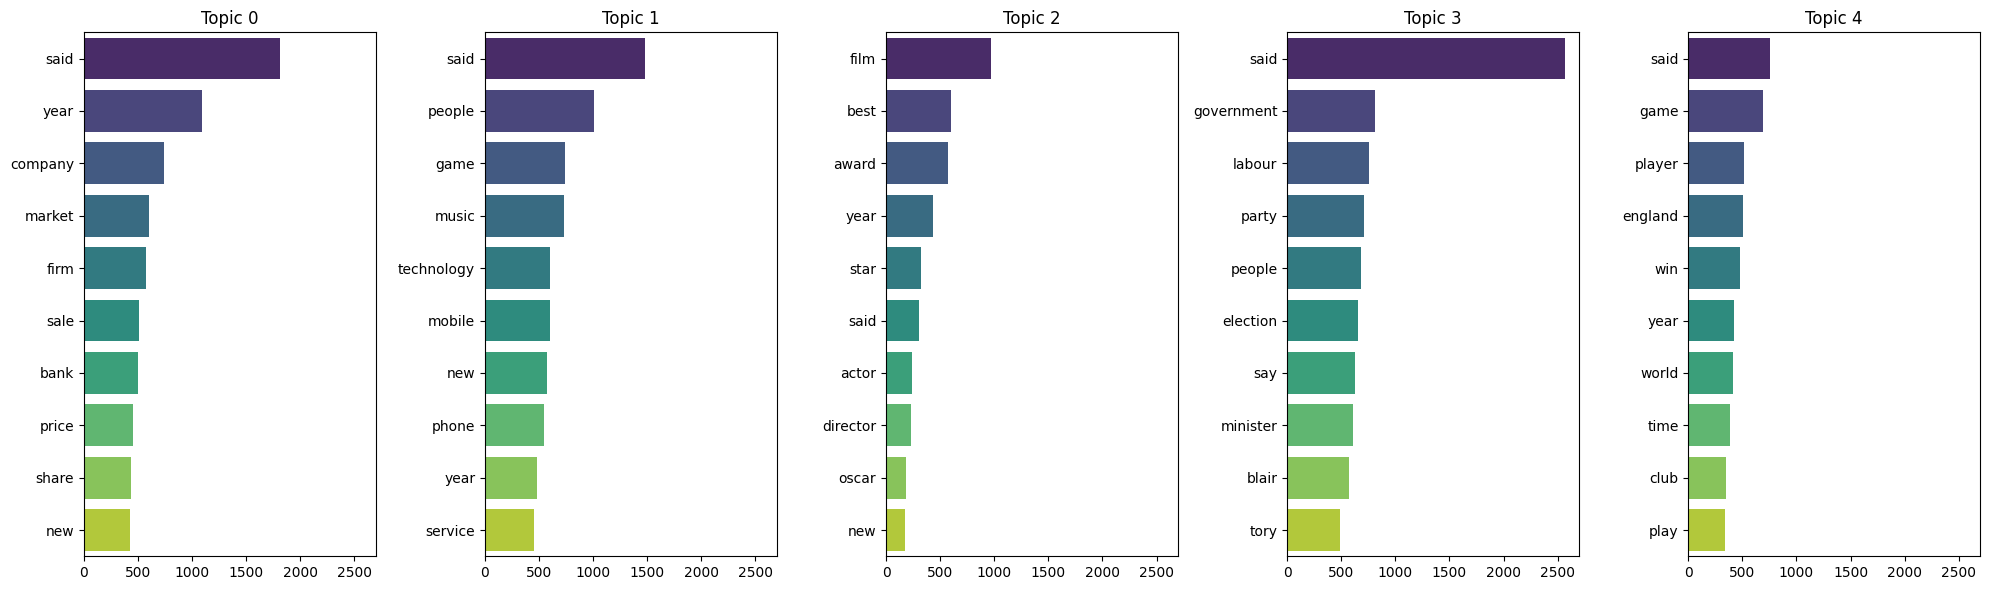

In [26]:
fig, axes = plt.subplots(1, n_topics, figsize=(20, 6), sharex=True)

for topic_idx, topic in enumerate(lda_model.components_):
    top_indices = topic.argsort()[:-11:-1]
    top_words = [feature_names[i] for i in top_indices]
    top_weights = [topic[i] for i in top_indices]

    ax = axes[topic_idx]
    sns.barplot(x=top_weights, y=top_words, ax=ax, hue=top_words, legend=False, palette="viridis")
    ax.set_title(f"Topic {topic_idx}")

plt.tight_layout()
plt.show()

In [27]:
# Map each topic to its best-matching category, then treat this like an accuracy score
topic_to_category = comparison.idxmax(axis=0)  # for each topic column, which category is dominant
df["predicted_category"] = df["dominant_topic"].map(topic_to_category)
accuracy = (df["predicted_category"] == df["category"]).mean()
print(f"LDA-to-category alignment: {accuracy:.2%}")

LDA-to-category alignment: 89.98%


In [28]:
!pip install wordcloud

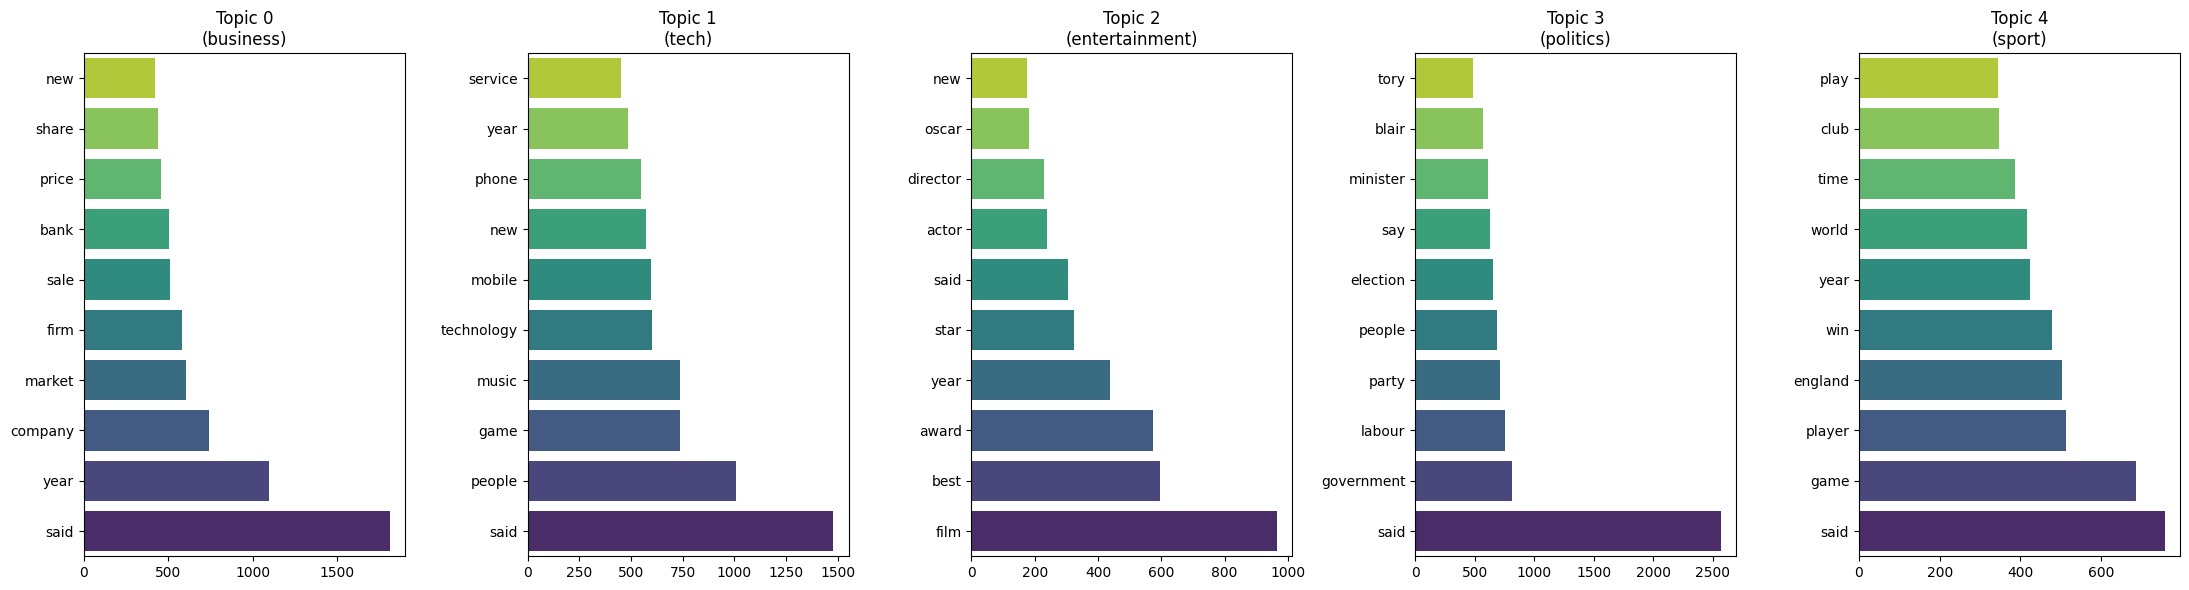

In [29]:
fig, axes = plt.subplots(1, n_topics, figsize=(22, 6), sharex=False)

for topic_idx, topic in enumerate(lda_model.components_):
    top_indices = topic.argsort()[:-11:-1]
    top_words = [feature_names[i] for i in top_indices]
    top_weights = [topic[i] for i in top_indices]

    ax = axes[topic_idx]
    sns.barplot(x=top_weights, y=top_words, ax=ax, hue=top_words, legend=False, palette="viridis")
    ax.set_title(f"Topic {topic_idx}\n({topic_to_category[topic_idx]})")
    ax.invert_yaxis()  # highest weight word on top

plt.tight_layout()
plt.show()

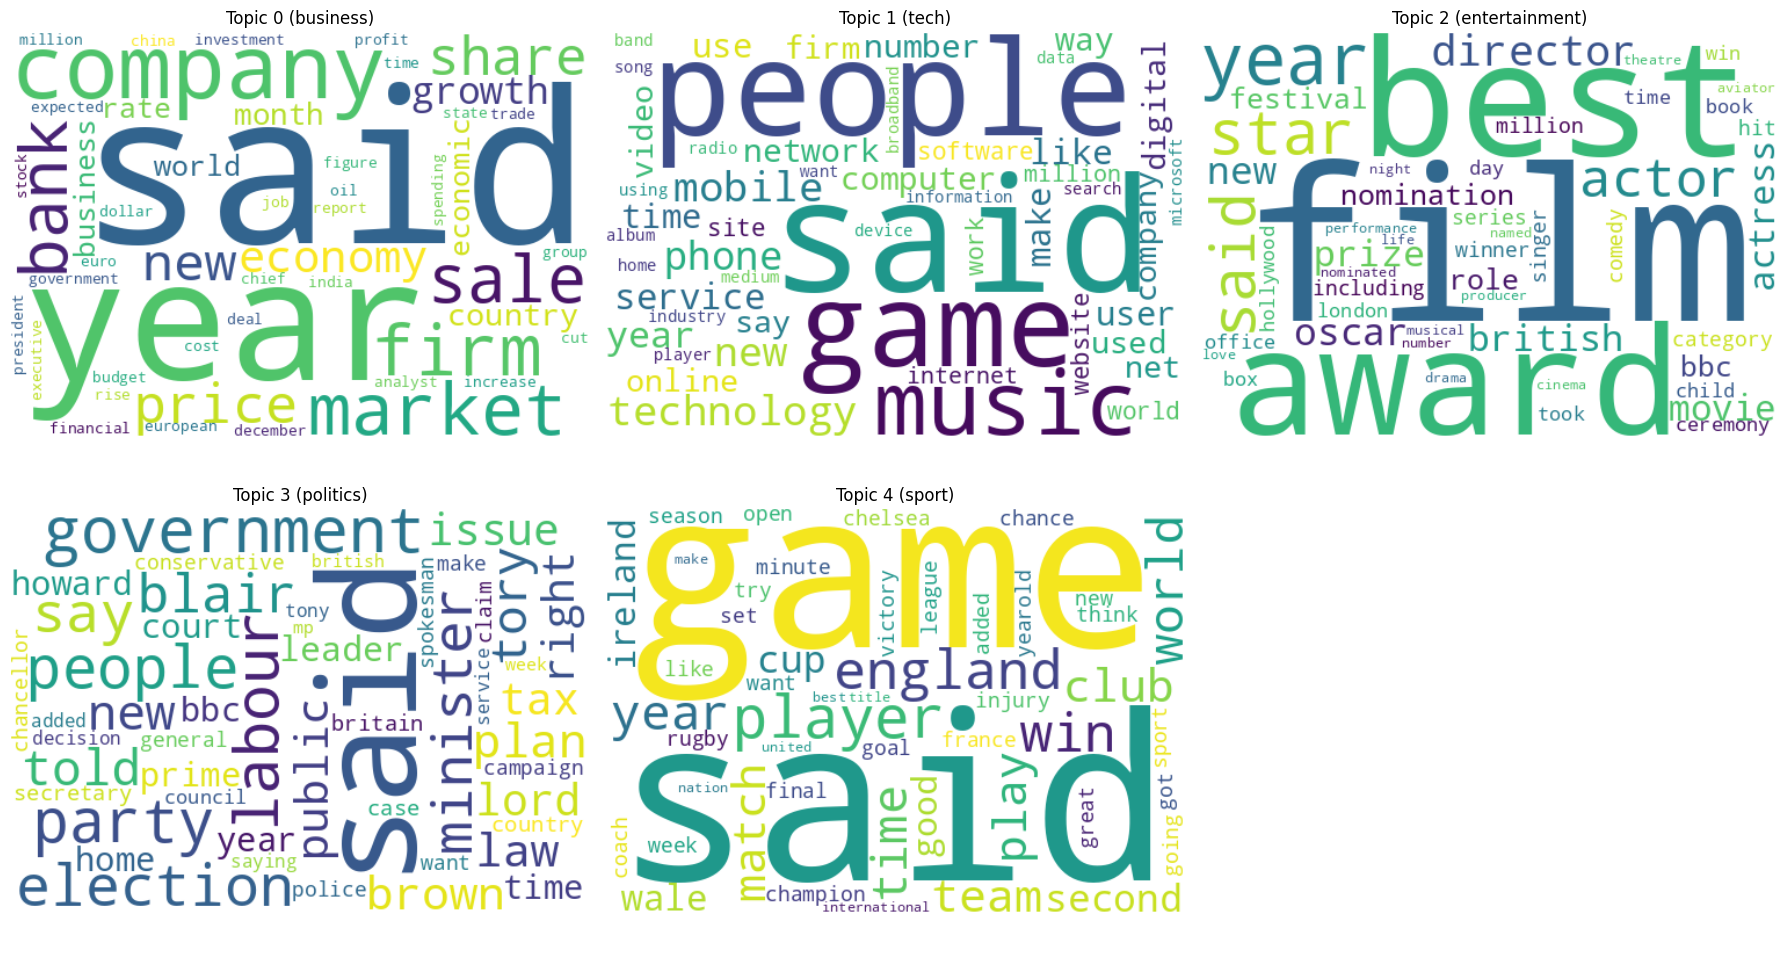

In [30]:
from wordcloud import WordCloud

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for topic_idx, topic in enumerate(lda_model.components_):
    word_freq = {feature_names[i]: topic[i] for i in topic.argsort()[:-51:-1]}  # top 50 words
    wc = WordCloud(width=500, height=350, background_color="white", colormap="viridis").generate_from_frequencies(word_freq)

    axes[topic_idx].imshow(wc, interpolation="bilinear")
    axes[topic_idx].set_title(f"Topic {topic_idx} ({topic_to_category[topic_idx]})")
    axes[topic_idx].axis("off")

axes[-1].axis("off")  # 6th subplot unused (only 5 topics) — hide it
plt.tight_layout()
plt.show()

In [31]:
# Log-likelihood: higher (less negative) = model fits the data better
# Perplexity: lower = model is less "confused" about the data — think of it as "how surprised is the model by this text"
print("Log-Likelihood:", lda_model.score(doc_term_matrix))
print("Perplexity:", lda_model.perplexity(doc_term_matrix))

Log-Likelihood: -2782244.8015529346
Perplexity: 2122.354317715114


In [32]:
def predict_topic(new_text, vectorizer, lda_model, topic_to_category):
    # Same cleaning pipeline used during training — must match exactly, or the vocabulary won't line up
    cleaned = clean_text(new_text)
    vectorized = vectorizer.transform([cleaned])   # note: transform, NOT fit_transform — we reuse the training vocabulary
    topic_probs = lda_model.transform(vectorized)[0]
    predicted_topic = topic_probs.argmax()

    print(f"Predicted topic #: {predicted_topic}")
    print(f"Predicted category: {topic_to_category[predicted_topic]}")
    print(f"Topic probabilities: {dict(zip(range(len(topic_probs)), topic_probs.round(3)))}")
    return predicted_topic

# Try it on something obviously sport-related
sample = "The striker scored a hat-trick in yesterday's match, sealing a dramatic win for the team in the final minutes of the game."
predict_topic(sample, vectorizer, lda_model, topic_to_category)

Predicted topic #: 4
Predicted category: sport
Topic probabilities: {0: np.float64(0.02), 1: np.float64(0.02), 2: np.float64(0.02), 3: np.float64(0.02), 4: np.float64(0.92)}


np.int64(4)

In [35]:
samples = {
    "business": "The company reported a sharp rise in quarterly profits after cutting costs and expanding into new markets, though investors remain cautious about rising interest rates and their effect on future growth.",

    "politics": "The prime minister faced tough questions in parliament today over the new tax proposal, as opposition leaders demanded a public vote before the policy is passed into law.",

    "sport": "The home team fought back from two goals down to win in extra time, with the captain scoring the winning goal in the final minute of the match to secure their place in the semi final.",

    "tech": "The new smartphone features a faster processor and an improved camera system, and early reviews suggest it could challenge rival devices when it launches globally next month.",

    "entertainment": "The actor's latest film topped the box office in its opening weekend, with critics praising the director's bold visual style and the lead performance as award-worthy.",
}

for category, text in samples.items():
    print(f"\n=== Expected: {category} ===")
    predict_topic(text, vectorizer, lda_model, topic_to_category)


=== Expected: business ===
Predicted topic #: 0
Predicted category: business
Topic probabilities: {0: np.float64(0.946), 1: np.float64(0.013), 2: np.float64(0.013), 3: np.float64(0.013), 4: np.float64(0.013)}

=== Expected: politics ===
Predicted topic #: 3
Predicted category: politics
Topic probabilities: {0: np.float64(0.012), 1: np.float64(0.012), 2: np.float64(0.012), 3: np.float64(0.953), 4: np.float64(0.012)}

=== Expected: sport ===
Predicted topic #: 4
Predicted category: sport
Topic probabilities: {0: np.float64(0.012), 1: np.float64(0.012), 2: np.float64(0.012), 3: np.float64(0.012), 4: np.float64(0.953)}

=== Expected: tech ===
Predicted topic #: 1
Predicted category: tech
Topic probabilities: {0: np.float64(0.017), 1: np.float64(0.932), 2: np.float64(0.017), 3: np.float64(0.017), 4: np.float64(0.017)}

=== Expected: entertainment ===
Predicted topic #: 2
Predicted category: entertainment
Topic probabilities: {0: np.float64(0.016), 1: np.float64(0.177), 2: np.float64(0.776)